# Diabetes Prediction

In [13]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
import joblib
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'seaborn'

In [2]:
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Load the diabetes dataset

In [3]:
raw_diabetes = pd.read_csv('diabetes_dataset_with_notes.csv')

## Data Exploration

In [4]:
print(f"Dataset shape: {raw_diabetes.shape}")

Dataset shape: (100000, 17)


In [5]:
raw_diabetes.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


In [6]:
raw_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

Drop the year, location, races columns, and clinical_notes columns

In [7]:
columns_drop = ['year', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 
                'race:Hispanic', 'race:Other', 'clinical_notes']
diabetes_data = raw_diabetes.drop(columns_drop, axis=1)

In [8]:
diabetes_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,32.0,0,0,never,27.32,5.0,100,0
1,Female,29.0,0,0,never,19.95,5.0,90,0
2,Male,18.0,0,0,never,23.76,4.8,160,0
3,Male,41.0,0,0,never,27.32,4.0,159,0
4,Female,52.0,0,0,never,23.75,6.5,90,0


In [9]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   hbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [10]:
diabetes_data.shape

(100000, 9)

Check for missing data

In [11]:
diabetes_data.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
hbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [12]:
diabetes_data.describe()

,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Plot histogram to observe the distribution for each column

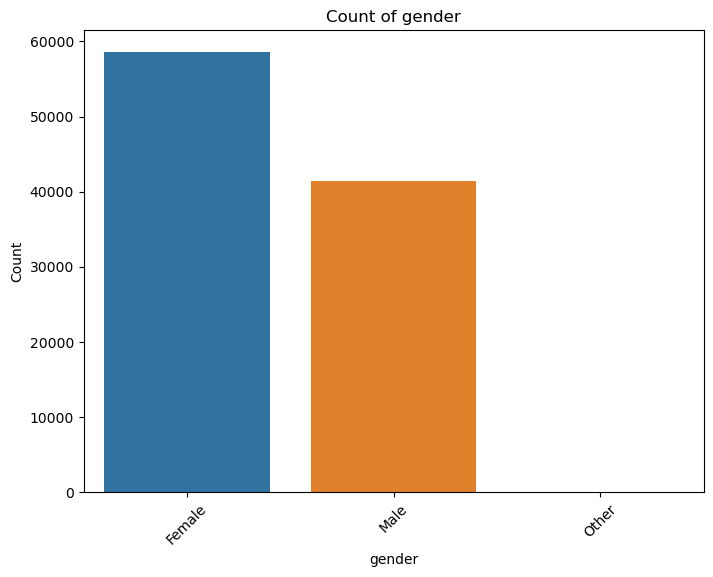

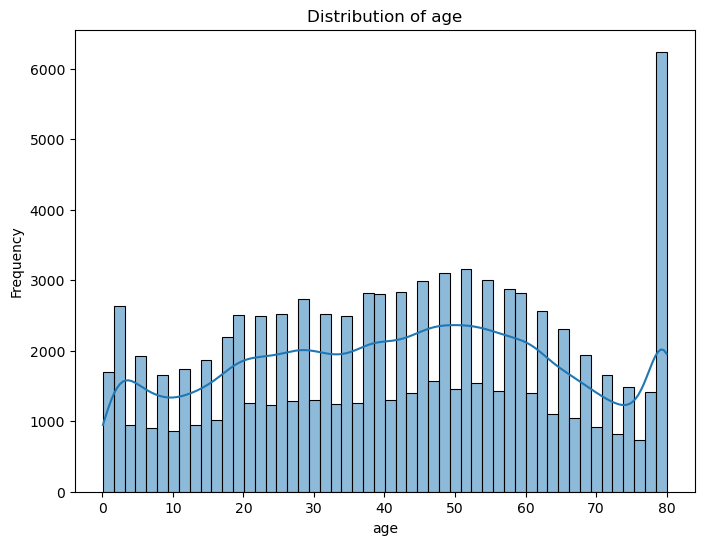

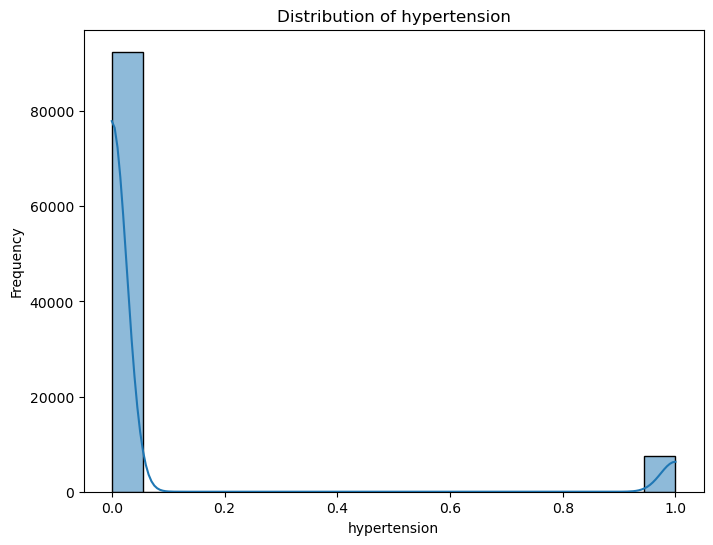

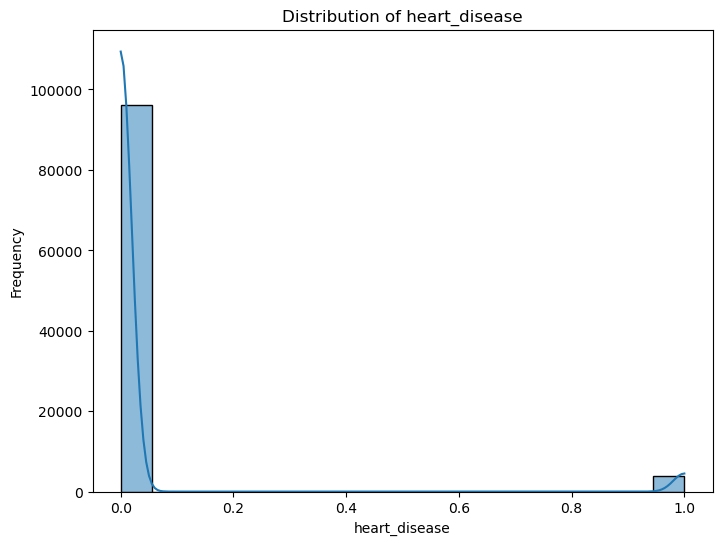

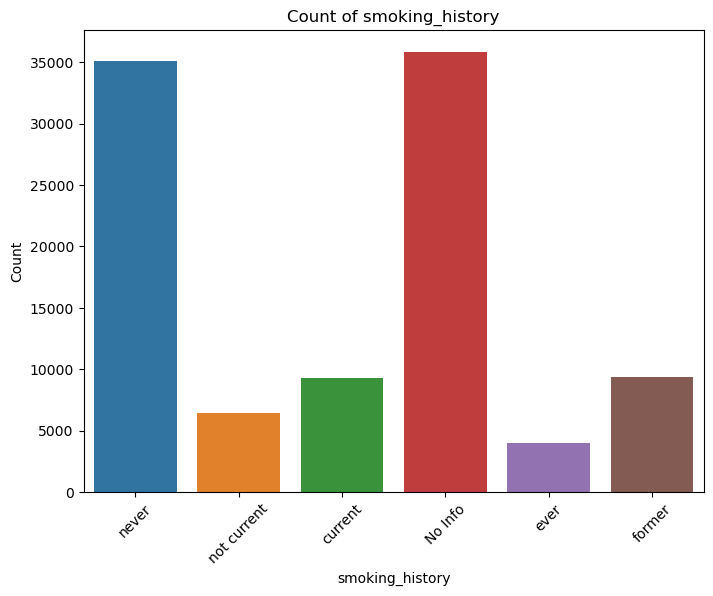

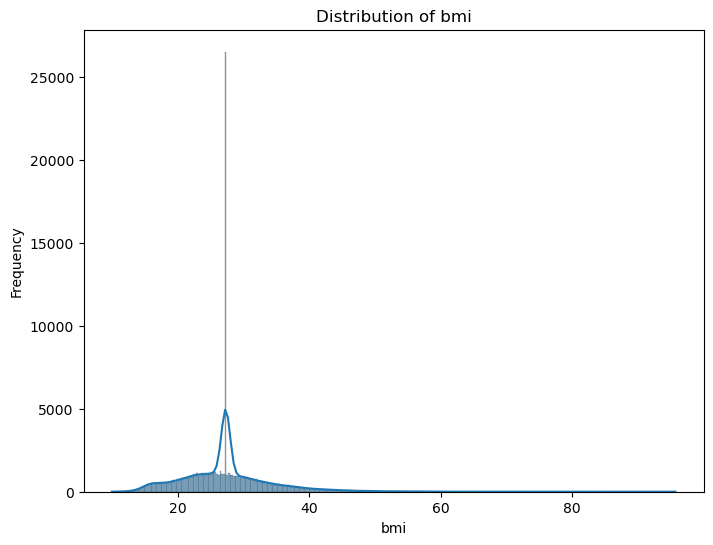

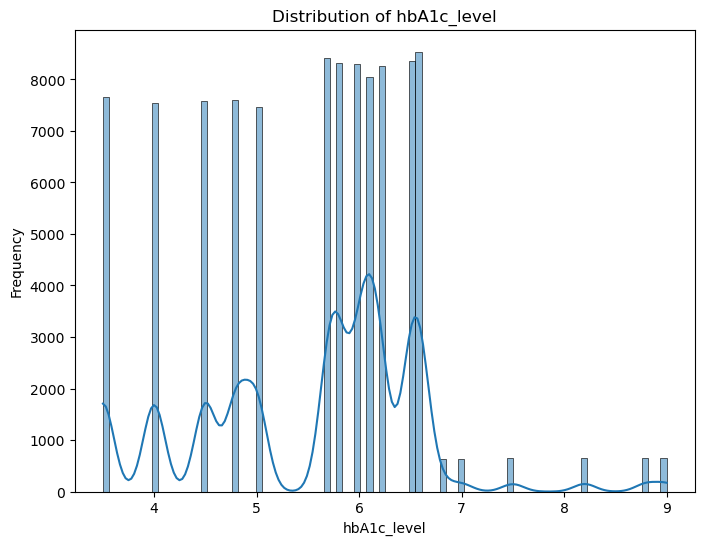

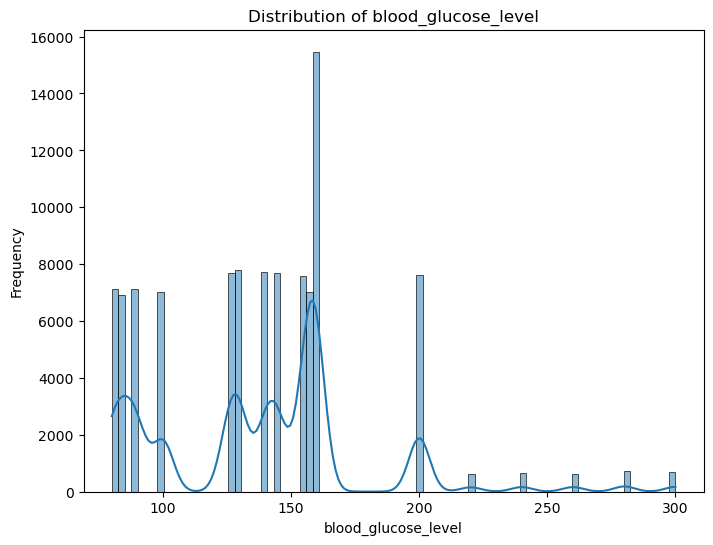

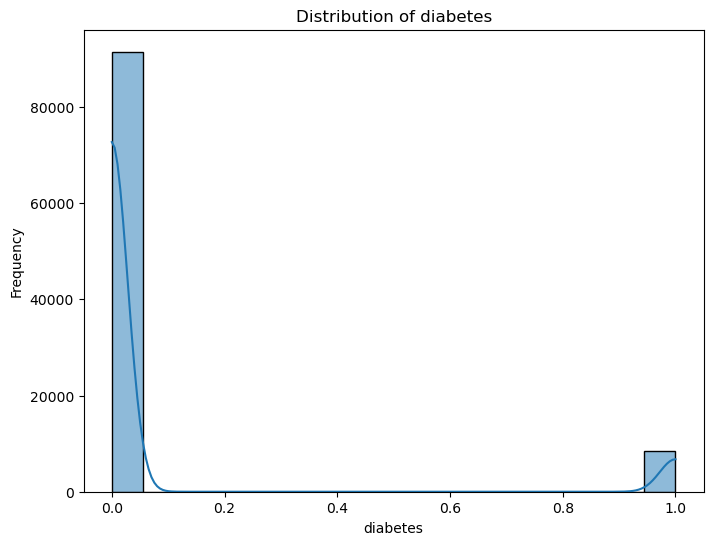

In [13]:
for column in diabetes_data.columns:
    if diabetes_data[column].dtype in ['int64', 'float64']:
        # Plot histograms for numerical columns
        plt.figure(figsize=(8, 6))
        sns.histplot(data=diabetes_data, x=column, kde=True)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()
    elif diabetes_data[column].dtype == 'object':
        # Plot counts for categorical columns
        plt.figure(figsize=(8, 6))
        sns.countplot(data=diabetes_data, x=column)
        plt.title(f'Count of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()

After visualizing the data for each column. we found out that there are 3 categories for gender (Male, Female, Other).
In the column age, there are values of 0. 

In [14]:
values_columns = ['gender','hypertension','heart_disease','smoking_history','diabetes']
for col in values_columns:
    print('Column:',col)
    print('Unique values:',diabetes_data[col].unique())
    print('\n')

Column: gender
Unique values: ['Female' 'Male' 'Other']


Column: hypertension
Unique values: [0 1]


Column: heart_disease
Unique values: [0 1]


Column: smoking_history
Unique values: ['never' 'not current' 'current' 'No Info' 'ever' 'former']


Column: diabetes
Unique values: [0 1]




Identify outliers in BMI by using the IQR method

In [15]:
def detect_outliers_iqr(data, column_name, multiplier=1.5):
    Q1 = data[column_name].quantile(0.25)
    Q3 = data[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = data[(data[column_name] < lower_bound) | (data[column_name] > upper_bound)]
    
    print(f"Q1 (25th percentile): {Q1:.2f}")
    print(f"Q3 (75th percentile): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {len(outliers)/len(data)*100:.2f}%")
    
    return outliers, lower_bound, upper_bound

In [16]:
iqr_outliers, iqr_lower, iqr_upper = detect_outliers_iqr(diabetes_data, 'bmi', 1.5)
print("\nIQR Outliers (BMI values):")
print(sorted(iqr_outliers['bmi'].values))
print()

Q1 (25th percentile): 23.63
Q3 (75th percentile): 29.58
IQR: 5.95
Lower bound: 14.71
Upper bound: 38.50
Number of outliers: 7086
Percentage of outliers: 7.09%

IQR Outliers (BMI values):
[10.01, 10.01, 10.08, 10.14, 10.19, 10.21, 10.3, 10.3, 10.34, 10.4, 10.5, 10.59, 10.6, 10.62, 10.64, 10.69, 10.76, 10.77, 10.77, 10.86, 10.86, 10.89, 10.91, 10.91, 10.98, 11.0, 11.0, 11.01, 11.01, 11.05, 11.08, 11.09, 11.1, 11.16, 11.16, 11.2, 11.24, 11.25, 11.25, 11.28, 11.31, 11.34, 11.34, 11.36, 11.38, 11.39, 11.4, 11.43, 11.43, 11.43, 11.44, 11.44, 11.47, 11.47, 11.51, 11.53, 11.53, 11.55, 11.56, 11.56, 11.65, 11.69, 11.74, 11.75, 11.82, 11.85, 11.88, 11.9, 11.91, 11.91, 11.93, 11.93, 11.94, 11.94, 11.95, 11.95, 11.95, 11.95, 11.97, 11.98, 11.98, 11.98, 11.99, 12.0, 12.0, 12.03, 12.03, 12.05, 12.08, 12.1, 12.1, 12.1, 12.12, 12.13, 12.14, 12.15, 12.15, 12.16, 12.16, 12.21, 12.21, 12.22, 12.22, 12.25, 12.26, 12.29, 12.3, 12.3, 12.32, 12.33, 12.36, 12.37, 12.37, 12.37, 12.37, 12.38, 12.38, 12.39, 12.3

In [17]:
print(iqr_lower)
print(iqr_upper)

14.705
38.504999999999995


We notice that the feature 'smoking' contains 'No Info' values which might consider as missing values

In [18]:
unique_smoking_history = diabetes_data['smoking_history'].unique()
for smoking_status in unique_smoking_history:
    count = diabetes_data[diabetes_data['smoking_history'] == smoking_status].shape[0]
    print(f"Number of records with smoking history '{smoking_status}': {count}")

Number of records with smoking history 'never': 35095
Number of records with smoking history 'not current': 6447
Number of records with smoking history 'current': 9286
Number of records with smoking history 'No Info': 35816
Number of records with smoking history 'ever': 4004
Number of records with smoking history 'former': 9352


## Data Cleaning and Preprocessing

Check for duplicated rows

In [19]:
diabetes_data.duplicated().sum()

3854

Remove the duplicates

In [20]:
diabetes_data.drop_duplicates(inplace=True)

In [21]:
diabetes_data.duplicated().sum()

0

Check for missing values

In [22]:
diabetes_data.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
hbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [23]:
diabetes_data.describe(include='object')

,gender,smoking_history
count,96146,96146
unique,3,6
top,Female,never
freq,56161,34398


In [24]:
diabetes_data.describe()

,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


Handling the age column

In [25]:
diabetes_data['age']

0        32.0
1        29.0
2        18.0
3        41.0
4        52.0
         ... 
99995    33.0
99996    80.0
99997    46.0
99998    51.0
99999    13.0
Name: age, Length: 96146, dtype: float64

As we can see the data type for the age column is float64. We have to change it to integer

We will select the values of age that are more than 5 to train the models

In [26]:
diabetes_data['age'] = diabetes_data['age'].round().astype(int)

In [27]:
diabetes_data['age']

0        32
1        29
2        18
3        41
4        52
         ..
99995    33
99996    80
99997    46
99998    51
99999    13
Name: age, Length: 96146, dtype: int32

In [28]:
diabetes_data = diabetes_data[diabetes_data['age'] >= 5]

In [29]:
diabetes_data.shape

(90973, 9)

Next, we need to handle the gender category

Drop the rows with the value of gender being 'Other'

In [30]:
num_other_gender = (diabetes_data['gender'] == 'Other').sum()
num_other_gender

18

In [31]:
diabetes_data = diabetes_data[diabetes_data['gender'] != 'Other']

In [32]:
diabetes_data['gender']

0        Female
1        Female
2          Male
3          Male
4        Female
          ...  
99995    Female
99996    Female
99997      Male
99998    Female
99999      Male
Name: gender, Length: 90955, dtype: object

Next, we will handle the outliers present in 'bmi'

Instead of dropping the rows with the outliers of bmi, we can replace the values of bmi that are greater than 70 to become 70.

In [33]:
diabetes_data.loc[diabetes_data['bmi'] > 70, 'bmi'] = 70

In [34]:
diabetes_data['bmi'].describe()

count    90955.000000
mean        27.821269
std          6.516151
min         10.010000
25%         24.140000
50%         27.320000
75%         30.210000
max         70.000000
Name: bmi, dtype: float64

Next, we will handle the smoking_history column. We will drop the rows with 'No Info' smoking history. 

In [35]:
diabetes_data = diabetes_data[diabetes_data['smoking_history'] != 'No Info']

After that, we treat the categories "current, former, ever, not current" as smokers, and only never as non-smoker.

In [36]:
diabetes_data['smoking_status'] = diabetes_data['smoking_history'].apply(lambda x: 0 if x == 'never' else 1)

In [37]:
diabetes_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_status
0,Female,32,0,0,never,27.32,5.0,100,0,0
1,Female,29,0,0,never,19.95,5.0,90,0,0
2,Male,18,0,0,never,23.76,4.8,160,0,0
3,Male,41,0,0,never,27.32,4.0,159,0,0
4,Female,52,0,0,never,23.75,6.5,90,0,0


Drop the column 'smoking_history'

In [38]:
diabetes_data = diabetes_data.drop('smoking_history', axis=1)

In [39]:
diabetes_data.head()

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_status
0,Female,32,0,0,27.32,5.0,100,0,0
1,Female,29,0,0,19.95,5.0,90,0,0
2,Male,18,0,0,23.76,4.8,160,0,0
3,Male,41,0,0,27.32,4.0,159,0,0
4,Female,52,0,0,23.75,6.5,90,0,0


Encode categorical columns

In [40]:
def perform_label_encoding(df, column_name):
    le = LabelEncoder()
    df[column_name] = le.fit_transform(df[column_name])
    return df, le

diabetes_data, gender_encoder = perform_label_encoding(diabetes_data, 'gender')

diabetes_data, smoking_encoder = perform_label_encoding(diabetes_data, 'smoking_status')

# Optional: Print the mapping to see what values were assigned
print("Gender encoding mapping:")
for i, label in enumerate(gender_encoder.classes_):
    print(f"{label}: {i}")

print("\nSmoking status encoding mapping:")
for i, label in enumerate(smoking_encoder.classes_):
    print(f"{label}: {i}")

Gender encoding mapping:
Female: 0
Male: 1

Smoking status encoding mapping:
0: 0
1: 1


In [41]:
cleaned_data = diabetes_data.copy()

In [42]:
cleaned_data.head()

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_status
0,0,32,0,0,27.32,5.0,100,0,0
1,0,29,0,0,19.95,5.0,90,0,0
2,1,18,0,0,23.76,4.8,160,0,0
3,1,41,0,0,27.32,4.0,159,0,0
4,0,52,0,0,23.75,6.5,90,0,0


In [43]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62627 entries, 0 to 99998
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               62627 non-null  int32  
 1   age                  62627 non-null  int32  
 2   hypertension         62627 non-null  int64  
 3   heart_disease        62627 non-null  int64  
 4   bmi                  62627 non-null  float64
 5   hbA1c_level          62627 non-null  float64
 6   blood_glucose_level  62627 non-null  int64  
 7   diabetes             62627 non-null  int64  
 8   smoking_status       62627 non-null  int64  
dtypes: float64(2), int32(2), int64(5)
memory usage: 4.3 MB


In [44]:
cleaned_data.describe()

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_status
count,62627.000000,62627.000000,62627.000000,62627.000000,62627.000000,62627.000000,62627.000000,62627.000000,62627.000000
mean,0.394686,46.997781,0.100117,0.048158,28.528390,5.568084,139.761221,0.112300,0.459466
std,0.488787,19.128765,0.300158,0.214102,6.502639,1.097370,42.290406,0.315737,0.498358
min,0.000000,5.000000,0.000000,0.000000,10.080000,3.500000,80.000000,0.000000,0.000000
25%,0.000000,31.000000,0.000000,0.000000,24.620000,4.800000,100.000000,0.000000,0.000000
50%,0.000000,47.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000,0.000000
75%,1.000000,62.000000,0.000000,0.000000,31.270000,6.200000,159.000000,0.000000,1.000000
max,1.000000,80.000000,1.000000,1.000000,70.000000,9.000000,300.000000,1.000000,1.000000


In [45]:
cleaned_data.shape

(62627, 9)

## Model Training

In [46]:
X = cleaned_data.drop('diabetes', axis=1)
y = cleaned_data['diabetes']

In [47]:
X.head()

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,smoking_status
0,0,32,0,0,27.32,5.0,100,0
1,0,29,0,0,19.95,5.0,90,0
2,1,18,0,0,23.76,4.8,160,0
3,1,41,0,0,27.32,4.0,159,0
4,0,52,0,0,23.75,6.5,90,0


In [48]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

In [49]:
#Split the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42)

In [50]:
#Normalize features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print(f"\nTraining set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")


Training set shape: (43838, 8)
Test set shape: (18789, 8)


## Random Forest Model

In [52]:
results = {}

In [53]:
# Random Forest with hyperparameter tuning
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [54]:
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), 
                       rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [55]:
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

In [56]:
# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

In [57]:
results['Random Forest'] = {
    'Accuracy': rf_accuracy,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1-Score': rf_f1,
    'Confusion Matrix': rf_cm
}

In [58]:
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print(f"Confusion Matrix:\n{rf_cm}")

Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 0.9614
Precision: 0.9905
Recall: 0.6720
F1-Score: 0.8008
Confusion Matrix:
[[16607    14]
 [  711  1457]]


## SVM Model

In [59]:
# SVM with hyperparameter tuning
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

In [60]:
svm_grid = GridSearchCV(SVC(random_state=42), svm_param_grid, 
                        cv=5, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'linear']},
             scoring='f1')

In [61]:
# Best SVM model
best_svm = svm_grid.best_estimator_
svm_pred = best_svm.predict(X_test_scaled)

In [62]:
# Evaluate SVM
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)
svm_cm = confusion_matrix(y_test, svm_pred)

In [63]:
results['SVM'] = {
    'Accuracy': svm_accuracy,
    'Precision': svm_precision,
    'Recall': svm_recall,
    'F1-Score': svm_f1,
    'Confusion Matrix': svm_cm
}

In [64]:
print(f"Best parameters: {svm_grid.best_params_}")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}")
print(f"Confusion Matrix:\n{svm_cm}")

Best parameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.9567
Precision: 0.9650
Recall: 0.6481
F1-Score: 0.7754
Confusion Matrix:
[[16570    51]
 [  763  1405]]


## Decision Tree

In [65]:
# Decision Tree with hyperparameter tuning
dt_param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

In [66]:
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                       dt_param_grid, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, 20, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1')

In [67]:
# Best Decision Tree model
best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)

In [68]:
# Evaluate Decision Tree
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)

In [69]:
results['Decision Tree'] = {
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1-Score': dt_f1,
    'Confusion Matrix': dt_cm
}

In [70]:
print(f"Best parameters: {dt_grid.best_params_}")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")
print(f"Confusion Matrix:\n{dt_cm}")

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Accuracy: 0.9612
Precision: 0.9806
Recall: 0.6771
F1-Score: 0.8011
Confusion Matrix:
[[16592    29]
 [  700  1468]]


## RNN Model

In [71]:
X_train_rnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_rnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [72]:
# Build RNN model
rnn_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [73]:
rnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("RNN Model Architecture:")
rnn_model.summary()

RNN Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 8, 64)             16896     
                                                                 
 dropout (Dropout)           (None, 8, 64)             0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 29857 (116.63 KB)


In [74]:
# Train RNN
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

rnn_history = rnn_model.fit(X_train_rnn, y_train,
                           epochs=100,
                           batch_size=32,
                           validation_split=0.2,
                           callbacks=[early_stopping],
                           verbose=0)

In [75]:
# Evaluate RNN
rnn_pred_prob = rnn_model.predict(X_test_rnn)
rnn_pred = (rnn_pred_prob > 0.5).astype(int).flatten()

rnn_accuracy = accuracy_score(y_test, rnn_pred)
rnn_precision = precision_score(y_test, rnn_pred)
rnn_recall = recall_score(y_test, rnn_pred)
rnn_f1 = f1_score(y_test, rnn_pred)
rnn_cm = confusion_matrix(y_test, rnn_pred)

588/588 [==============================] - 7s 7ms/step


In [76]:
results['RNN (LSTM)'] = {
    'Accuracy': rnn_accuracy,
    'Precision': rnn_precision,
    'Recall': rnn_recall,
    'F1-Score': rnn_f1,
    'Confusion Matrix': rnn_cm
}

In [77]:
print(f"Accuracy: {rnn_accuracy:.4f}")
print(f"Precision: {rnn_precision:.4f}")
print(f"Recall: {rnn_recall:.4f}")
print(f"F1-Score: {rnn_f1:.4f}")
print(f"Confusion Matrix:\n{rnn_cm}")

Accuracy: 0.9605
Precision: 0.9951
Recall: 0.6610
F1-Score: 0.7943
Confusion Matrix:
[[16614     7]
 [  735  1433]]


## TensorFlow Deep Neural Network

In [78]:
# Build TensorFlow DNN model
tf_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [79]:
tf_model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print("TensorFlow DNN Model Architecture:")
tf_model.summary()

TensorFlow DNN Model Architecture:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 128)               1152      
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)   

In [80]:
# Train TensorFlow model
tf_history = tf_model.fit(X_train_scaled, y_train,
                         epochs=100,
                         batch_size=32,
                         validation_split=0.2,
                         callbacks=[early_stopping],
                         verbose=0)

In [81]:
# Evaluate TensorFlow model
tf_pred_prob = tf_model.predict(X_test_scaled)
tf_pred = (tf_pred_prob > 0.5).astype(int).flatten()

tf_accuracy = accuracy_score(y_test, tf_pred)
tf_precision = precision_score(y_test, tf_pred)
tf_recall = recall_score(y_test, tf_pred)
tf_f1 = f1_score(y_test, tf_pred)
tf_cm = confusion_matrix(y_test, tf_pred)

588/588 [==============================] - 3s 5ms/step


In [82]:
results['TensorFlow DNN'] = {
    'Accuracy': tf_accuracy,
    'Precision': tf_precision,
    'Recall': tf_recall,
    'F1-Score': tf_f1,
    'Confusion Matrix': tf_cm
}

In [83]:
print(f"Accuracy: {tf_accuracy:.4f}")
print(f"Precision: {tf_precision:.4f}")
print(f"Recall: {tf_recall:.4f}")
print(f"F1-Score: {tf_f1:.4f}")
print(f"Confusion Matrix:\n{tf_cm}")

Accuracy: 0.9611
Precision: 0.9979
Recall: 0.6647
F1-Score: 0.7979
Confusion Matrix:
[[16618     3]
 [  727  1441]]


## Evaluation

In [84]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['Accuracy'] for model in results],
    'Precision': [results[model]['Precision'] for model in results],
    'Recall': [results[model]['Recall'] for model in results],
    'F1-Score': [results[model]['F1-Score'] for model in results]
})

In [85]:
print(results_df.round(4))

            Model  Accuracy  Precision  Recall  F1-Score
0   Random Forest    0.9614     0.9905  0.6720    0.8008
1             SVM    0.9567     0.9650  0.6481    0.7754
2   Decision Tree    0.9612     0.9806  0.6771    0.8011
3      RNN (LSTM)    0.9605     0.9951  0.6610    0.7943
4  TensorFlow DNN    0.9611     0.9979  0.6647    0.7979


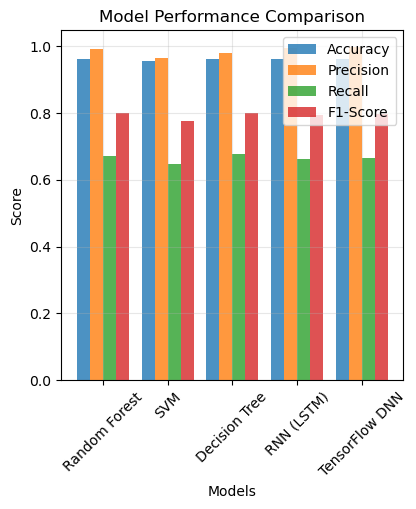

In [86]:
# Visualization of results
plt.figure(figsize=(15, 10))

# Metrics comparison
plt.subplot(2, 3, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric, alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x + width*1.5, results_df['Model'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

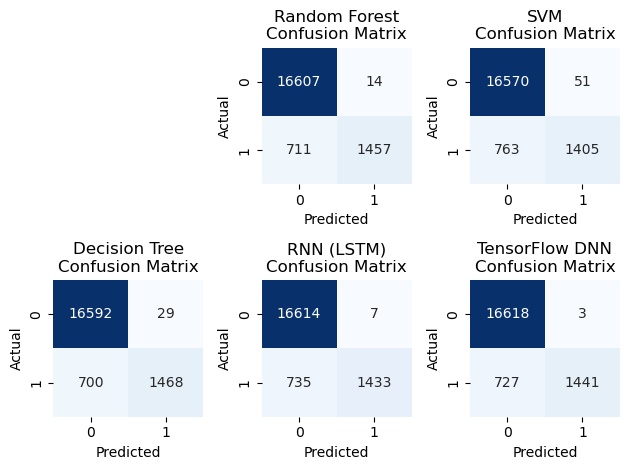

In [87]:
# Confusion matrices
for i, model in enumerate(results.keys()):
    if i < 4:  # Adjust for 5 models total (2x3 grid can show 4 confusion matrices)
        plt.subplot(2, 3, i+2)
        sns.heatmap(results[model]['Confusion Matrix'], annot=True, fmt='d', 
                    cmap='Blues', cbar=False)
        plt.title(f'{model}\nConfusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

# Add 5th confusion matrix in a separate subplot layout if needed
if len(results) > 4:
    remaining_models = list(results.keys())[4:]
    for i, model in enumerate(remaining_models):
        plt.subplot(2, 3, 6)
        sns.heatmap(results[model]['Confusion Matrix'], annot=True, fmt='d', 
                    cmap='Blues', cbar=False)
        plt.title(f'{model}\nConfusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [88]:
available_features = X.columns

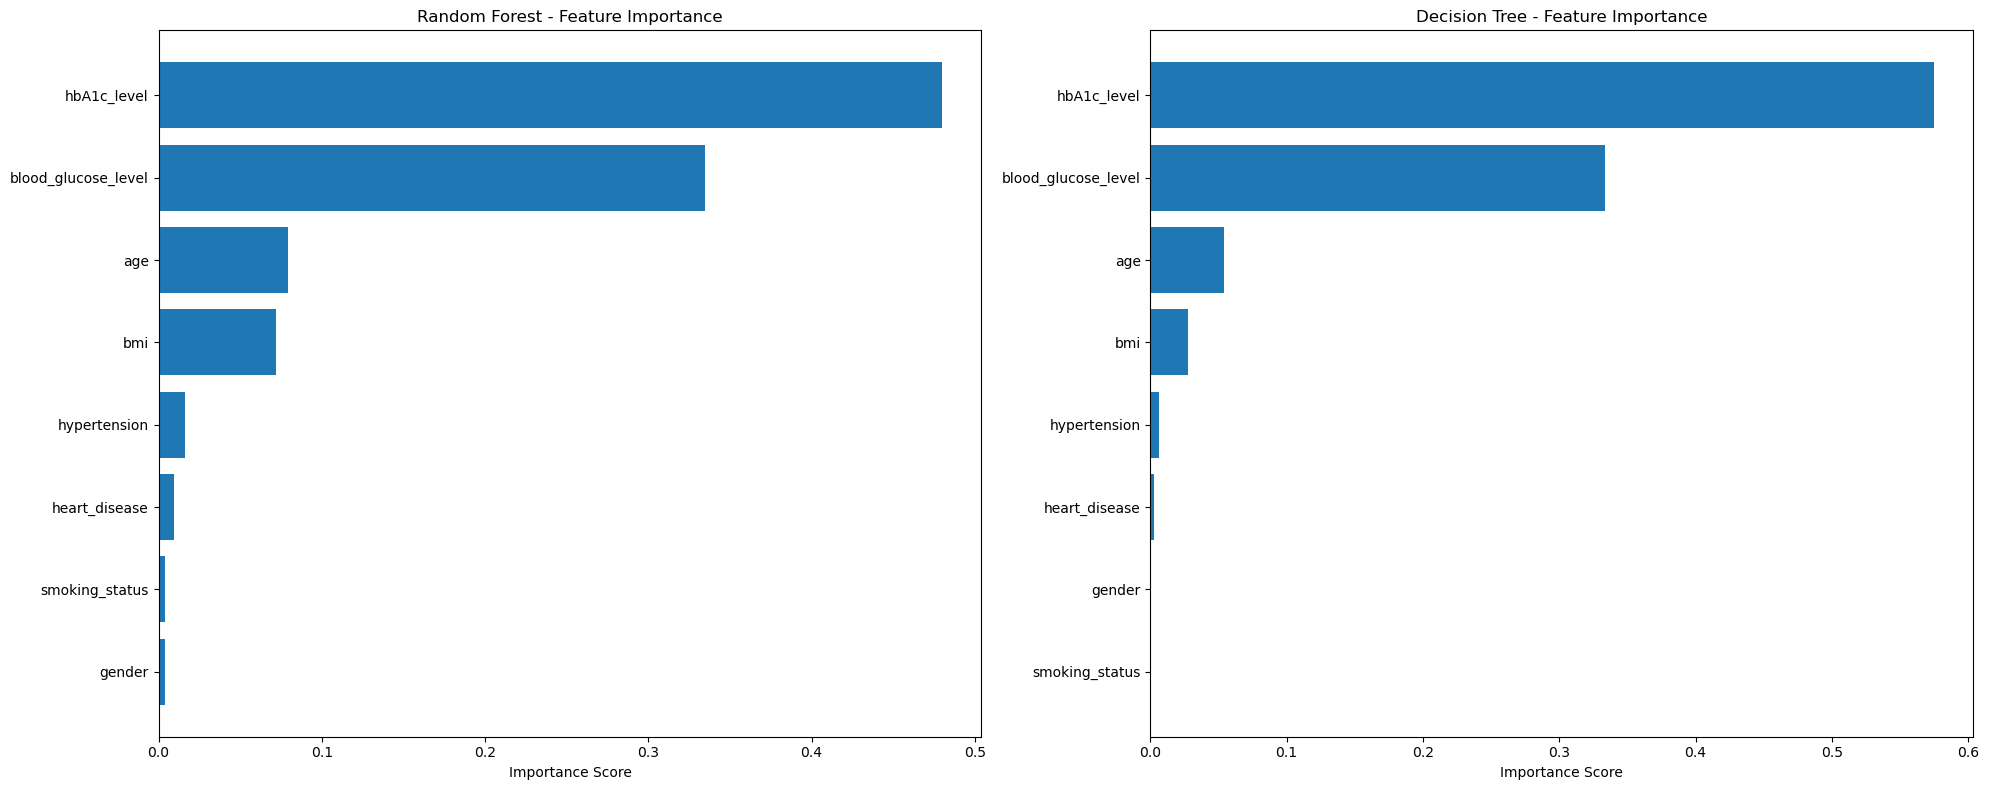

In [89]:
# Feature importance for Random Forest and Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest Feature Importance
rf_feature_importance = pd.DataFrame({
    'Feature': available_features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'])
axes[0].set_title('Random Forest - Feature Importance')
axes[0].set_xlabel('Importance Score')

# Decision Tree Feature Importance
dt_feature_importance = pd.DataFrame({
    'Feature': available_features,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(dt_feature_importance['Feature'], dt_feature_importance['Importance'])
axes[1].set_title('Decision Tree - Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

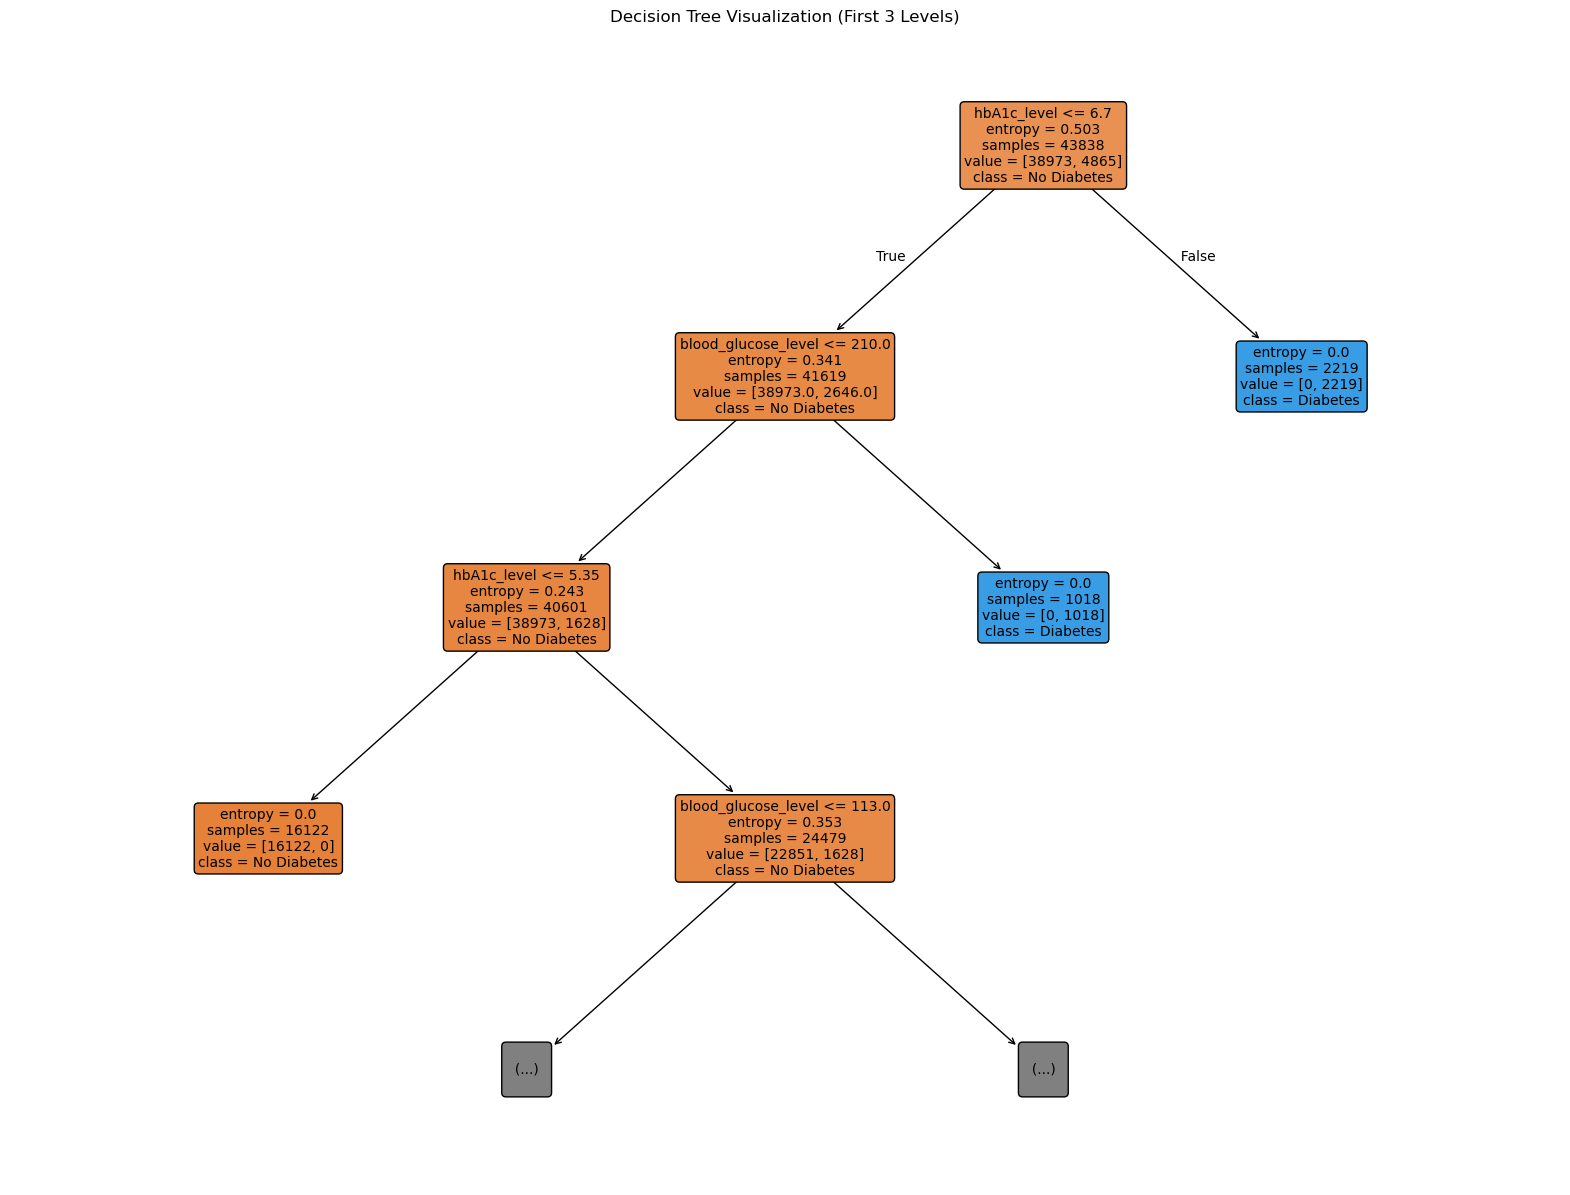

In [90]:
# Decision Tree Visualization
plt.figure(figsize=(20, 15))
from sklearn.tree import plot_tree

plot_tree(best_dt, 
          feature_names=available_features,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Limit depth for readability
plt.title('Decision Tree Visualization (First 3 Levels)')
plt.show()

In [91]:
# Display feature importance values
print("\nRandom Forest Feature Importance Rankings:")
rf_feature_importance_desc = rf_feature_importance.sort_values('Importance', ascending=False)
for idx, row in rf_feature_importance_desc.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

print("\nDecision Tree Feature Importance Rankings:")
dt_feature_importance_desc = dt_feature_importance.sort_values('Importance', ascending=False)
for idx, row in dt_feature_importance_desc.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")


Random Forest Feature Importance Rankings:
hbA1c_level: 0.4800
blood_glucose_level: 0.3350
age: 0.0795
bmi: 0.0719
hypertension: 0.0159
heart_disease: 0.0097
smoking_status: 0.0041
gender: 0.0039

Decision Tree Feature Importance Rankings:
hbA1c_level: 0.5748
blood_glucose_level: 0.3332
age: 0.0542
bmi: 0.0280
hypertension: 0.0064
heart_disease: 0.0023
gender: 0.0007
smoking_status: 0.0003


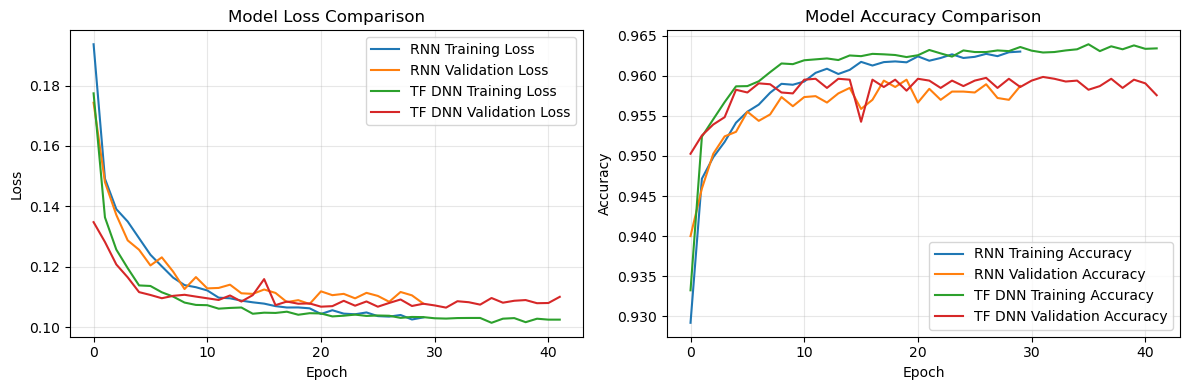

In [92]:
# Training history for neural networks
if 'rnn_history' in locals():
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(rnn_history.history['loss'], label='RNN Training Loss')
    plt.plot(rnn_history.history['val_loss'], label='RNN Validation Loss')
    plt.plot(tf_history.history['loss'], label='TF DNN Training Loss')
    plt.plot(tf_history.history['val_loss'], label='TF DNN Validation Loss')
    plt.title('Model Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(rnn_history.history['accuracy'], label='RNN Training Accuracy')
    plt.plot(rnn_history.history['val_accuracy'], label='RNN Validation Accuracy')
    plt.plot(tf_history.history['accuracy'], label='TF DNN Training Accuracy')
    plt.plot(tf_history.history['val_accuracy'], label='TF DNN Validation Accuracy')
    plt.title('Model Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [93]:
## Model Recommendations

print("\n=== MODEL RECOMMENDATIONS ===")

# Find best performing model
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1_score = results_df['F1-Score'].max()

print(f"Best performing model: {best_model_name}")
print(f"Best F1-Score: {best_f1_score:.4f}")

print("\nModel Analysis:")
for model in results_df['Model']:
    row = results_df[results_df['Model'] == model].iloc[0]
    print(f"\n{model}:")
    print(f"  - Strengths: ", end="")
    
    if model == 'Random Forest':
        print("Feature importance, handles overfitting well, robust to outliers")
    elif model == 'Decision Tree':
        print("Highly interpretable, easy to understand, handles categorical features well")
    elif model == 'RNN (LSTM)':
        print("Can capture sequential patterns, good for time-series aspects")
    elif model == 'TensorFlow DNN':
        print("Deep learning capabilities, can learn complex patterns")
    elif model == 'SVM':
        print("Good for high-dimensional data, effective with small datasets")
    
    print(f"  - Performance: Accuracy={row['Accuracy']:.3f}, F1={row['F1-Score']:.3f}")

print(f"\nRecommendation: Use {best_model_name} for deployment as it achieved the highest F1-score.")
print("Consider ensemble methods combining multiple models for potentially better performance.")
print("\nDecision Tree provides the most interpretable results for medical professionals.")
print("Random Forest offers good performance with feature importance insights.")


=== MODEL RECOMMENDATIONS ===
Best performing model: Decision Tree
Best F1-Score: 0.8011

Model Analysis:

Random Forest:
  - Strengths: Feature importance, handles overfitting well, robust to outliers
  - Performance: Accuracy=0.961, F1=0.801

SVM:
  - Strengths: Good for high-dimensional data, effective with small datasets
  - Performance: Accuracy=0.957, F1=0.775

Decision Tree:
  - Strengths: Highly interpretable, easy to understand, handles categorical features well
  - Performance: Accuracy=0.961, F1=0.801

RNN (LSTM):
  - Strengths: Can capture sequential patterns, good for time-series aspects
  - Performance: Accuracy=0.961, F1=0.794

TensorFlow DNN:
  - Strengths: Deep learning capabilities, can learn complex patterns
  - Performance: Accuracy=0.961, F1=0.798

Recommendation: Use Decision Tree for deployment as it achieved the highest F1-score.
Consider ensemble methods combining multiple models for potentially better performance.

Decision Tree provides the most interpretabl

## Saving the Models

In [94]:
# Random Forest Model
joblib.dump(best_rf, "rf_model.pk1")

# SVM Model
joblib.dump(best_svm, "svm_model.pk1")

# Decision Model
joblib.dump(best_dt, "dt_model.pk1")

['dt_model.pk1']

In [95]:
# RNN
rnn_model.save("RNN_model")

INFO:tensorflow:Assets written to: RNN_model\assets


INFO:tensorflow:Assets written to: RNN_model\assets


In [96]:
# TensorFlow Deep Neural Network
tf_model.save("TF_model")

INFO:tensorflow:Assets written to: TF_model\assets


INFO:tensorflow:Assets written to: TF_model\assets
